## Image Resizing, Scaling, and Interpolation
### Image Resizing

Image resizing refers to changing the dimensions (width and height) of an image. This can be done to:

* Reduce storage size
 
* Fit a specific display requirement

* Prepare images for model input in machine learning

### Image Scaling

Image scaling is a type of resizing where the dimensions are changed proportionally by a scale factor:

*    Upscaling increases image size

*    Downscaling reduces image size

Example:

*    Scaling an image by 0.5 reduces both width and height to half.

*    Scaling by 2 doubles the image size.

### 🔁 Interpolation

When resizing or scaling an image, interpolation determines how pixel values are calculated in the new image.

Common methods include:

`cv2.INTER_NEAREST` : Simplest method.Each pixel in the resized image is assigned the value of the nearest pixel in the original image

`cv2.INTER_LINEAR` : Uses the average of the nearest four pixels to calculate the new pixel value

`cv2.INTER_CUBIC` : Consider the nearest 16 pixels to calculate the new pixel value,providing smoother results.

`cv2.INTER_AREA` : Calculates the average pixel value in the area of the original image that maps to a single pixel in the resized image.

`cv2.INTER_LANCZOS4` : Uses a mathematical formula(Lanczos kernal) to consider the nearest 8X8 pixel neighborhood for each pixel.Produces high-quality results but is computationally expensive.

In [1]:
import cv2
import matplotlib.pyplot as plt

In [26]:
image = cv2.imread("asserts/img1.png")

In [27]:
image_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

(np.float64(-0.5), np.float64(560.5), np.float64(863.5), np.float64(-0.5))

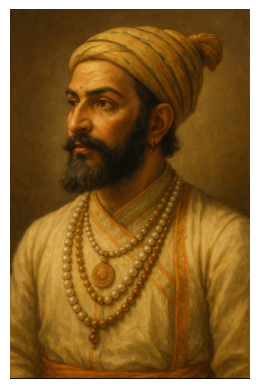

In [28]:
plt.imshow(image_rgb)
plt.axis("off")

## Image Resizing

In [29]:
print(image_rgb.shape)

(864, 561, 3)


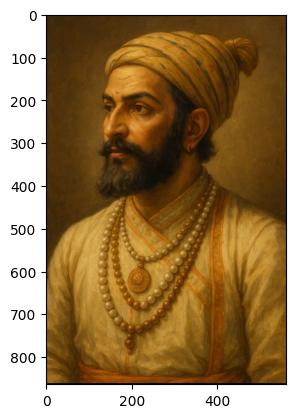

In [37]:
new_height,new_width = 100,100

resized_image = cv2.resize(image_rgb,(new_width,new_height))
plt.imshow(image_rgb)

## Image Scaling

(432, 280, 3)


Text(0.5, 1.0, 'Scaled Image')

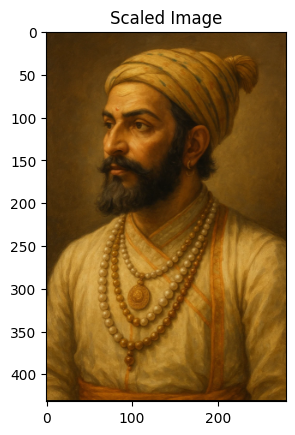

In [38]:
scale_percentage = 50
s_width = int(image_rgb.shape[1]*scale_percentage/100)
s_height = int(image_rgb.shape[0]*scale_percentage/100)

scaled_image = cv2.resize(image_rgb,(s_width,s_height),interpolation=cv2.INTER_AREA)

print(scaled_image.shape)
plt.imshow(scaled_image)
plt.title("Scaled Image")

## Interpolation

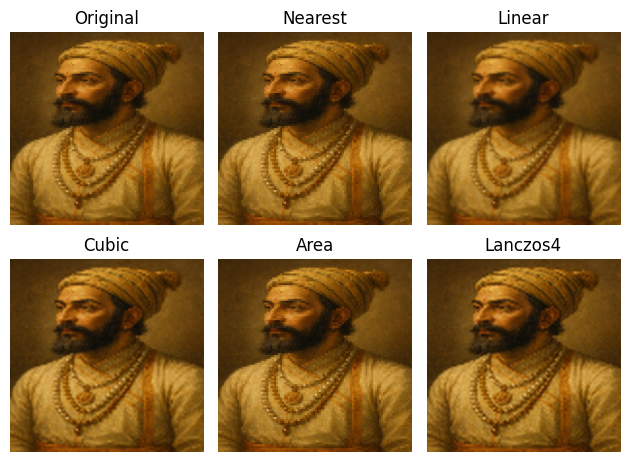

In [43]:
resize_width = 600
resize_height = 600

image_rgb_resized = cv2.resize(image_rgb,(100,100))

methods = {
    'Nearest':cv2.INTER_NEAREST,
    'Linear':cv2.INTER_LINEAR,
    'Cubic':cv2.INTER_CUBIC,
    'Area':cv2.INTER_AREA,
    'Lanczos4':cv2.INTER_LANCZOS4
}

resized_images = {}
for name,method in methods.items():
    resized_images[name] = cv2.resize(image_rgb_resized,(resize_width,resize_height),interpolation=method)
    cv2.imwrite(f"./{name}.png",resized_images[name])

plt.subplot(2,3,1)
plt.imshow(image_rgb_resized)
plt.title('Original')
plt.axis('off')

for i,(name,resized_image) in enumerate(resized_images.items(),start=2):
    plt.subplot(2,3,i)
    plt.imshow(resized_image)
    plt.title(name)
    plt.axis('off')

plt.tight_layout()
plt.show()

